## Getting started

In [1]:
from pathlib import Path
import spyne

Localize the data, change this as needed.

In [2]:
data_folder = Path("data")
date = "251204"
cell_n = "cell0001"

imaging_folder = data_folder / date / cell_n

## Dataset inizialization

### Imaging dataset

Let's start with the imaging dataset. This will load metadata and pre-process the imaging frame sequences.

In [3]:
dataset = spyne.ImagingDataset(imaging_folder)

✓ Loaded metadata from data\251204\cell0001\processed\imaging\metadata.h5.
✓ Loaded 220 processed arrays from: data\251204\cell0001\processed\imaging\processed_imaging.h5


If they are not already saved, let's save the loaded data and metadata (```.h5``` format) for faster fututre loading.

In [ ]:
dataset.save_metadata()
dataset.save_processed_data()

Have a glance at recorded imaging data. This will open an external window (press **q** to close it).

In [ ]:
# Indexing corresponds to [roi_n][sweep_n] (two channels by default)
dataset[6][2].show()

In [ ]:
# To see a single channel [roi number][sweep number][channel number]
dataset[6][2][0].show()

---

### Spines dataset

Now let's generate a spine dataset. This will need additional analysis (see below).

In [4]:
# Create a SpineDataset for spine analysis
spine_dataset = spyne.SpineDataset(dataset)

Loading .h5 data: 100%|██████████| 3/3 [00:00<00:00,  4.19it/s]


Let's launch spine segmentation to collect all spines masks from ROIs. By setting ```save=True``` we create predictions and metadata ```.h5``` files. In addition, these data are stored as ```spine_dataset``` attributes.

In [ ]:
# TODO: this still points to a private method, need to create a public one
spine_dataset._collect_spines_and_dendrites_data(save=True)

In [5]:
print(f"Number of spines detected: {len(spine_dataset.spines_data)}")

Number of spines detected: 390


### Visual inspection of spine locations

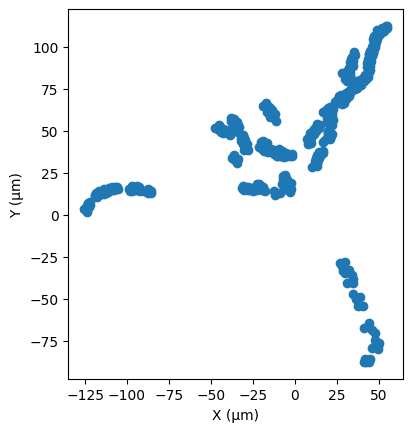

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

spyne.plot.scatter(spine_dataset.spines_data, ax=ax)

ax.set(
    aspect='equal',
    xlabel='X (µm)',
    ylabel='Y (µm)',
)
plt.show()

Now, let's collect the fluorescence variation time series from each spine.  By setting ```save=True``` we create ```.h5``` files for $\frac{\Delta F}{F_{0}}$, zscore and timestamps time series for both CA3 and BLA.

In [7]:
# TODO: this still points to a private method, need to create a public one
spine_dataset._collect_timeseries(save=True)

Saved zscores_CA3.h5 to data\251204\cell0001\processed\spines
Saved dFF_CA3.h5 to data\251204\cell0001\processed\spines
Saved ts_CA3.h5 to data\251204\cell0001\processed\spines
Saved zscores_BLA.h5 to data\251204\cell0001\processed\spines
Saved dFF_BLA.h5 to data\251204\cell0001\processed\spines
Saved ts_BLA.h5 to data\251204\cell0001\processed\spines


Next, we detect calcium events among the collected timeseries, using custom ```calcium_event_classifier```. This generates ```.h5``` files containing probability values of a trace containing an event.

In [8]:
# TODO: this still points to a private method, need to create a public one
spine_dataset._calcium_events_predictions(save=True)

c:\Users\dcupolillo\AppData\Local\anaconda3\envs\2p\lib\site-packages\calcium_event_classifier\core\inference.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint

Saved calcium_event_probabilities_BLA.h5 to data\251204\cell0001\analysis\spines
Saved calcium_event_probabilities_CA3.h5 to data\251204\cell0001\analysis\spines


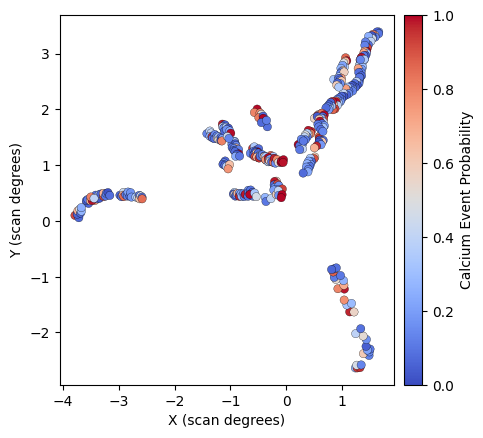

In [ ]:
import matplotlib.colors as mcolors
import numpy as np

fig, ax = plt.subplots()

# Define colormap and normalization
cmap = plt.get_cmap("coolwarm")
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

# Map maximum calcium event probabilities across 5 sweeps to colors
max_predictions = np.max(spine_dataset.calcium_event_probabilities_BLA, axis=1)
spine_colors = [cmap(norm(prediction)) for prediction in max_predictions]

spyne.plot.scatter(
    spine_dataset.spines_data,
    ax=ax,
    scan_angle=True,
    color=spine_colors,
    edgecolor="black",
    linewidth=0.2,
)
ax.set(
    aspect='equal',
    xlabel='X (scan degrees)',
    ylabel='Y (scan degrees)',
)

# Add colorbar
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Max. calcium event probability')

plt.show()